## Decision Tree Classification: Iris
<img src="local_data/IrisPhoto.png"></src>


In [1]:
#%pip install graphviz ipython matplotlib numpy pandas pydotplus scikit-learn

Before running, install the following packages: 
- GraphViz software https://graphviz.org/_pages/Download/Download_windows.html
- Add GraphViz to windows path:
    - In "System Properties", pick "Advanced" tab. 
    - Environment Variables->System Variables-> Path -> Edit -> New
    - Add the correct path: e.g., <br> c:\Program Files (x86)\Graphviz2.38\bin\   <br>   C:\Program Files\Graphviz\bin 
- In Anaconda prompt, install:
    - pip install graphviz pydotplus  <br>   or  
    - conda install graphviz pydotplus  
- Restart Jupiter.  

### Load data

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
iris_data = load_iris()
# transform to pandas
iris = pd.DataFrame(iris_data['data'],columns=iris_data['feature_names'])
iris['class'] = iris_data['target_names'][iris_data['target']]
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X=iris[iris_data.feature_names]
y=iris['class']

In [4]:
y.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

## Train decision tree

In [5]:
from sklearn import tree
import numpy as np
from sklearn.model_selection import cross_val_score
clf_tree = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)  # using entropy as the criterion for splitting and limiting the depth of the tree to 3 to avoid overfitting
clf_tree.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [6]:
# generate a new observation
obs_1 = np.array((9.9,3.4,1.4,2.2)).reshape(1,-1)
# create a dataframe for the observation to ensure the order of the features matches
# the training data and avoid warnings of the predict function 
obs_1_df = pd.DataFrame(obs_1, columns=iris_data['feature_names']) 
clf_tree.predict(obs_1_df)

array(['setosa'], dtype=object)

## Generate Graphical Representation of the Tree 

digraph Tree {
node [shape=box, fontname="helvetica"] ;
edge [fontname="helvetica"] ;
0 [label="x[2] <= 2.45\nentropy = 1.585\nsamples = 150\nvalue = [50, 50, 50]"] ;
1 [label="entropy = 0.0\nsamples = 50\nvalue = [50, 0, 0]"] ;
0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;
2 [label="x[3] <= 1.75\nentropy = 1.0\nsamples = 100\nvalue = [0, 50, 50]"] ;
0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="False"] ;
3 [label="x[2] <= 4.95\nentropy = 0.445\nsamples = 54\nvalue = [0, 49, 5]"] ;
2 -> 3 ;
4 [label="entropy = 0.146\nsamples = 48\nvalue = [0, 47, 1]"] ;
3 -> 4 ;
5 [label="entropy = 0.918\nsamples = 6\nvalue = [0, 2, 4]"] ;
3 -> 5 ;
6 [label="x[2] <= 4.85\nentropy = 0.151\nsamples = 46\nvalue = [0, 1, 45]"] ;
2 -> 6 ;
7 [label="entropy = 0.918\nsamples = 3\nvalue = [0, 1, 2]"] ;
6 -> 7 ;
8 [label="entropy = 0.0\nsamples = 43\nvalue = [0, 0, 43]"] ;
6 -> 8 ;
}


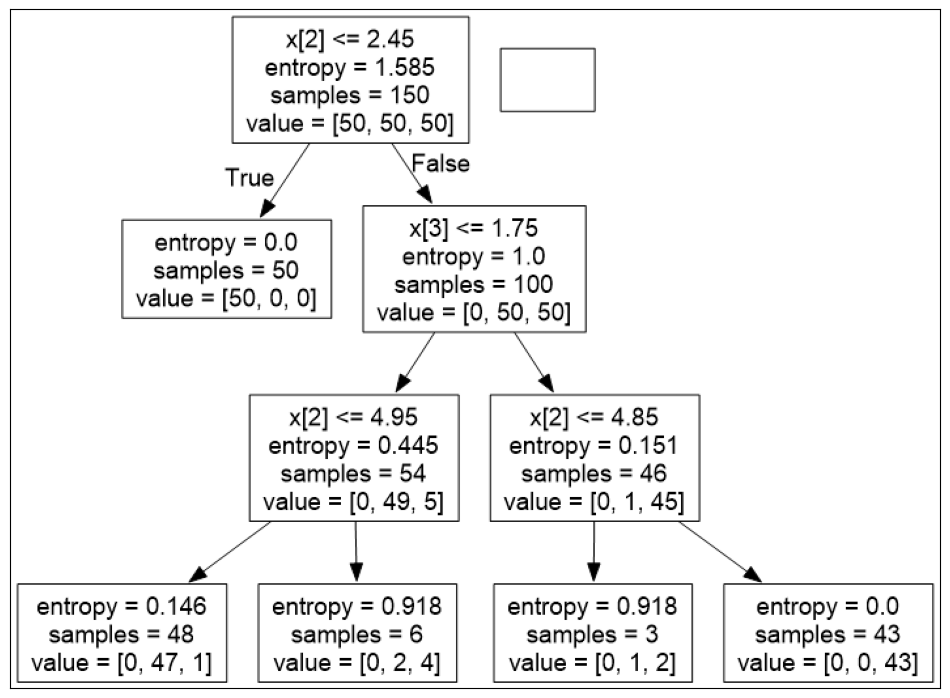

In [7]:
import matplotlib.pyplot as plt
from IPython.display import Image
import pydotplus

dot_data = tree.export_graphviz(clf_tree, out_file=None)
print(dot_data)

graph = pydotplus.graph_from_dot_data(dot_data) 
graph.write_png('iris.png');
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(plt.imread('iris.png'));
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()

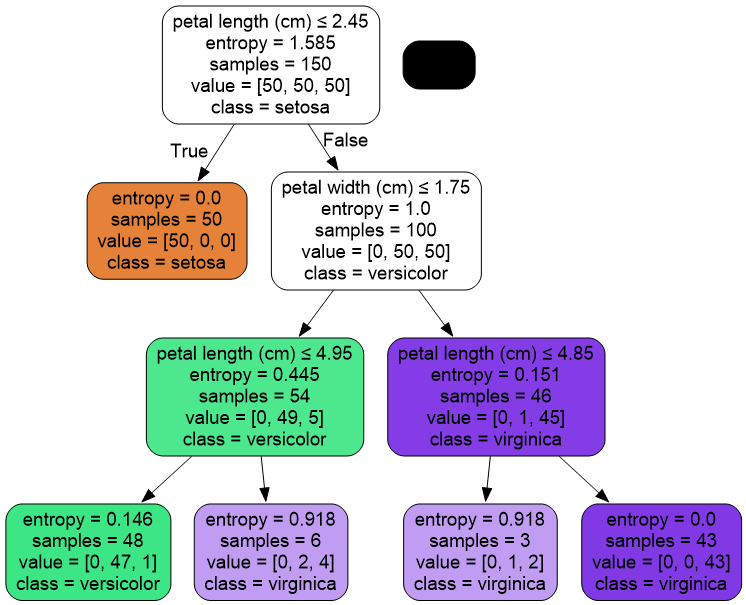

In [8]:
dot_data = tree.export_graphviz(clf_tree, out_file=None, 
                         feature_names=iris_data.feature_names,  
                         class_names=iris_data.target_names,  
                         filled=True, rounded=True,  
                         special_characters=True)  
graph = pydotplus.graph_from_dot_data(dot_data) 
Image(graph.create_png())  